In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

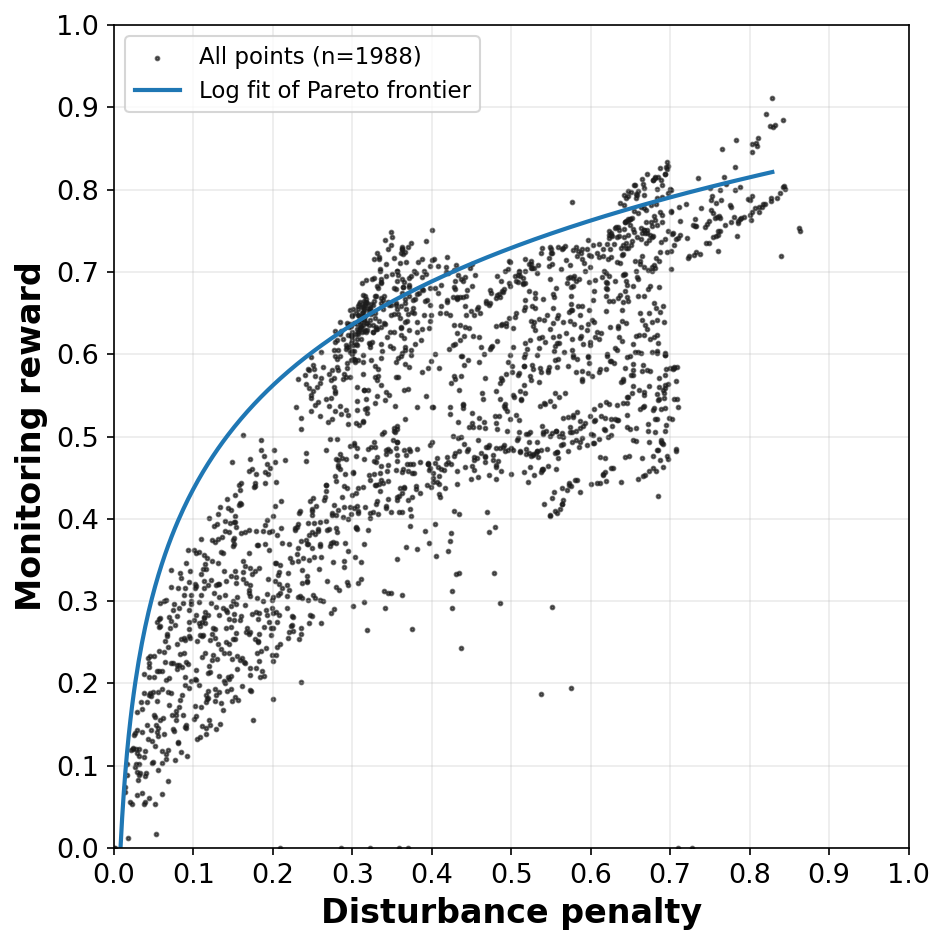

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xcol = "p_disturbance"
ycol = "r_monitoring"

base_file = Path("table/all_model_episode_rewards.csv")
sparse_file = Path("table/all_model_episode_rewards_sparse.csv")

# -------------------------
# load / accumulate results
# -------------------------
df_new = pd.read_csv(base_file)

if sparse_file.exists():
    df_existing = pd.read_csv(sparse_file)
    df_all = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df_all = df_new.copy()

# remove duplicates only on plotted coordinates
df_all = df_all.drop_duplicates(subset=[xcol, ycol]).copy()

# save updated accumulated dataset
df_all.to_csv(sparse_file, index=False)

# keep valid rows only
df_all = df_all[[xcol, ycol]].dropna().copy()

# -------------------------
# Pareto frontier
# minimize x, maximize y
# -------------------------
pts = df_all[[xcol, ycol]].to_numpy()

# sort by x ascending, y descending
pts = pts[np.lexsort((-pts[:, 1], pts[:, 0]))]

pareto = []
best_y = -np.inf

for px, py in pts:
    if py > best_y:
        pareto.append((px, py))
        best_y = py

pareto = np.array(pareto)

# -------------------------
# logarithmic fit to Pareto
# y = a * ln(x + c) + b
# choose c so x + c > 0
# -------------------------
x_p = pareto[:, 0]
y_p = pareto[:, 1]

eps = 1e-3
c = max(eps, -x_p.min() + eps)   # ensures positivity inside log
X = np.log(x_p + c)

a, b = np.polyfit(X, y_p, 1)

x_fit = np.linspace(x_p.min(), x_p.max(), 400)
y_fit = a * np.log(x_fit + c) + b

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=150)

# all points
ax.scatter(
    df_all[xcol],
    df_all[ycol],
    s=12,
    alpha=0.65,
    color="#1C1C1C",
    marker=".",
    label=f"All points (n={len(df_all)})"
)

# # Pareto frontier
# ax.plot(
#     pareto[:, 0],
#     pareto[:, 1],
#     color="blue",
#     linewidth=1.5,
#     label=f"Pareto frontier (n={len(pareto)})"
# )

# log fit
ax.plot(
    x_fit,
    y_fit,
    color="tab:blue",
    linestyle="-",
    linewidth=2.0,
    label="Log fit of Pareto frontier"
)

# labels
ax.set_xlabel("Disturbance penalty", fontsize=16, fontweight="bold")
ax.set_ylabel("Monitoring reward", fontsize=16, fontweight="bold")

# ticks: [0,1] with 11 ticks
ticks = np.linspace(0, 1, 11)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(axis="both", labelsize=13)

# grid
ax.grid(True, alpha=0.25)

# no plot title here if this will become a paper figure
# use figure caption in LaTeX instead of ax.set_title(...)

ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("figures/pareto.png")
plt.show()